In [ ]:
# Instalación de bibliotecas
!pip -q install amplpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 6.8 MB/s eta 0:00:00


In [ ]:
# 1. Instalación e inicialización de AMPL con tu licencia Community Edition
from amplpy import ampl_notebook

# Inicializa AMPL en Colab con tu UUID (Community Edition) Inicializar AMPL
ampl = ampl_notebook(
    modules=["highs", "cbc", "gurobi", "cplex"],  # solvers disponibles
    license_uuid="936b618d-a013-406f-9809-49679f557c26"
)

Licensed to AMPL Academic Community Edition License for <m.godoyseplveda@uandresbello.edu>.


In [ ]:
%%writefile 3_1_5.mod
var x1 >= 0;
var x2 >= 0;

maximize Z: 2*x1 + x2;

s.t. c1: x2            <= 10;
s.t. c2: 2*x1 + 5*x2   <= 60;
s.t. c3: x1  +   x2    <= 18;
s.t. c4: 3*x1 +   x2   <= 44;


Writing 3_1_5.mod


In [ ]:
%%writefile 3_1_5.dat
# No se requieren parámetros externos para este modelo.


Writing 3_1_5.dat


In [ ]:
from amplpy import AMPL

ampl = AMPL()
ampl.read("3_1_5.mod")
ampl.readData("3_1_5.dat")

ampl.option['solver'] = 'highs'
ampl.solve()
ampl.display('x1', 'x2', 'Z')


HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 31
3 simplex iterations
0 barrier iterations
x1 = 13
x2 = 5
Z = 31



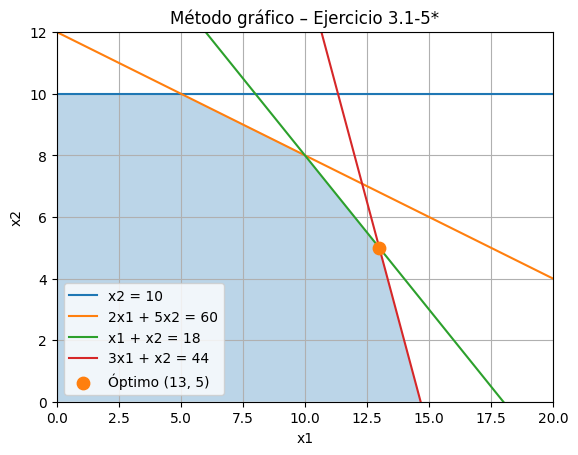

In [ ]:
import numpy as np, matplotlib.pyplot as plt

x1 = np.linspace(0, 20, 400)
x2_lines = {
    "x2 = 10":              np.full_like(x1, 10),
    "2x1 + 5x2 = 60":       (60 - 2*x1)/5,
    "x1 + x2 = 18":         18 - x1,
    "3x1 + x2 = 44":        44 - 3*x1
}

# región factible: mínimo de todas las rectas y ≥0
x2_feas = np.maximum(0, np.minimum.reduce(list(x2_lines.values())))

plt.figure()
for label, y in x2_lines.items():
    plt.plot(x1, y, label=label)

plt.fill_between(x1, 0, x2_feas, alpha=0.3)
plt.scatter(13, 5, s=80, label="Óptimo (13, 5)", zorder=5)

plt.xlim(0, 20); plt.ylim(0, 12)
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("Método gráfico – Ejercicio 3.1-5*")
plt.legend(); plt.grid(True); plt.show()
